In [1]:
#%load_ext autoreload
#%autoreload 2

import os
from os.path import join
import random
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from skimage import measure
from torch.utils.data import Dataset, DataLoader
import torchio as tio
from torchio.data import SubjectsLoader

from monai.networks.nets import UNet, AttentionUnet

os.environ["CUDA_VISIBLE_DEVICES"] = "0" # TODO: multiple ?
import torch
import torch.nn as nn
from pathlib import Path
from datetime import datetime

from torch.nn import DataParallel

seed = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(seed)

In [2]:
import sys
print('__Python VERSION:', sys.version)
print('__pyTorch VERSION:', torch.__version__)
print('__CUDA VERSION')
from subprocess import call
! nvcc --version
print('__CUDNN VERSION:', torch.backends.cudnn.version())
print('__Number CUDA Devices:', torch.cuda.device_count())
print('__Devices')
call(["nvidia-smi", "--format=csv", "--query-gpu=index,name,driver_version,memory.total,memory.used,memory.free"])
print('Active CUDA Device: GPU', torch.cuda.current_device())
print ('Available devices ', torch.cuda.device_count())
print ('Current cuda device ', torch.cuda.current_device())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

__Python VERSION: 3.9.21 (main, Dec 11 2024, 16:35:24) [MSC v.1929 64 bit (AMD64)]
__pyTorch VERSION: 2.8.0.dev20250416+cu128
__CUDA VERSION
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:42:46_Pacific_Standard_Time_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
__CUDNN VERSION: 90701
__Number CUDA Devices: 1
__Devices
Active CUDA Device: GPU 0
Available devices  1
Current cuda device  0


In [3]:
from utils.loading_utils import *
from utils.logging import *
from visualization.visualization import *
#from ml.dataset_ import BrainMetDatasetPreloaded, GridSamplerWrapper
from ml.dataset_ import BrainMetPytorchDataset, BrainMetFullVolumeDataset, BrainMetPytorchDatasetValidation
from ml.trainer import Trainer, Att3DUNET_Trainer, load_trained_model

In [4]:
%load_ext tensorboard
%reload_ext tensorboard

%tensorboard --logdir runs

Launching TensorBoard...

In [5]:
#from tensorboard import notebook
#notebook.list()
#notebook.display(port=6006, height=1000)

#http://127.0.0.1:6006/?darkMode=true

In [6]:
TRAIN_ROOT_DIR  = './MICCAI-LH-BraTS2025-MET-Challenge-Training/'
HELPER_ROOT_DIR = './training_helper/'

# !--------------------------------------------------------------
dataset = BrainMetPytorchDataset(TRAIN_ROOT_DIR, patch_size=(128, 128, 96), do_raffine=True)
# !--------------------------------------------------------------

train_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1])

train_dataloader = DataLoader(train_dataset, batch_size=16, num_workers=0, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=16, num_workers=0, shuffle=False)

Found UCSD-Training subfolder: ./training_helper/UCSD - Training
Total # samples: 13 in ./training_helper/



In [7]:
def dice_loss(probs, targets, epsilon=1e-5):
    # Assumes probs: [B, C, H, W, D], targets: [B, C, H, W, D]
    intersection = (probs * targets).sum(dim=(2, 3, 4))
    union = probs.sum(dim=(2, 3, 4)) + targets.sum(dim=(2, 3, 4))
    dice = 2. * intersection / (union + epsilon)
    return 1 - dice.mean()

def loss_fn(logits, target):
    target = target.to(torch.long)
    if target.ndim == 5 and target.shape[1] == 1:
        target = target[:, 0]              # [B, H, W, D]
    ce = torch.nn.functional.cross_entropy(logits, target)

    # --- Dice loss ---
    probs = torch.softmax(logits, dim=1)  # [B, C, H, W, D]
    one_hot_target = torch.nn.functional.one_hot(target, num_classes=logits.shape[1])  # [B, H, W, D, C]
    one_hot_target = one_hot_target.permute(0, 4, 1, 2, 3).float()    # [B, C, H, W, D]

    dice = dice_loss(probs, one_hot_target)

    return ce + dice

def dice_score(preds, targets, epsilon=1e-5):
    if targets.ndim == 5 and targets.shape[1] == 1:
        targets = targets[:, 0]  # Fix channel dim

    num_classes = int(torch.max(targets).item()) + 1
    dice_scores = []

    for c in range(num_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()

        intersection = (pred_c * target_c).sum(dim=(1, 2, 3))
        union = pred_c.sum(dim=(1, 2, 3)) + target_c.sum(dim=(1, 2, 3))

        dice = (2 * intersection + epsilon) / (union + epsilon)
        dice_scores.append(dice)

    return torch.stack(dice_scores).mean()

# Run1

In [10]:
from ml.a3d_attention_unet import UNet3D

model_1 = UNet3D(
    in_channels=4,
    out_channels=5,
    final_sigmoid=False,
    f_maps = 32, # should be 32
    layer_order='crg',
    num_groups=8 # should be 8
).to(device)
#------------------------------------------------------------------
# apparently geht des so leicht....
# TODO: musst aber oben bei dein imports dann einstellen welche visible sin
# model_1 = torch.nn.DataParallel(model_1, device_ids=[0, 1, 2])
#-----------------------------------------------------------------

optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=1.5e-4, weight_decay=5e-3)

Epoch: 1 [train-loss]:   0%|          | 0/1 [00:00<?, ?it/s]D:\Schule\JKU\MA_2_Semester\MedicalImaging\ml\trainer.py:444: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Scalar.cpp:23.)
  losses.append(loss_value.item())
Epoch: 1 [valid-loss]: 100%|██████████| 1/1 [00:04<00:00,  4.76s/it, valid-loss_loss=2.5335]



Epoch Summary:
  train-loss: 2.6635
  mean-dice-score: 0.2826
  WT-Dice: 0.0512
  TC-Dice: 0.0143
  ET-Dice: 0.0097
  WT-NSD: 0.0224
  WT-Sensitivity: 0.9697
  WT-Specificity: 0.0586
  WT-Precision: 0.0263
  TC-NSD: 0.0064
  TC-Sensitivity: 0.6653
  TC-Specificity: 0.7581
  TC-Precision: 0.0072
  ET-NSD: 0.0058
  ET-Sensitivity: 0.2178
  ET-Specificity: 0.8847
  ET-Precision: 0.0050
  valid-loss: 2.5335


Epoch: 2 [valid-loss]: 100%|██████████| 1/1 [00:04<00:00,  4.01s/it, valid-loss_loss=2.5360]



Epoch Summary:
  train-loss: 2.6044
  mean-dice-score: 0.2742
  WT-Dice: 0.0194
  TC-Dice: 0.0020
  ET-Dice: 0.0028
  WT-NSD: 0.0194
  WT-Sensitivity: 0.9653
  WT-Specificity: 0.0466
  WT-Precision: 0.0098
  TC-NSD: 0.0021
  TC-Sensitivity: 0.6766
  TC-Specificity: 0.7440
  TC-Precision: 0.0010
  ET-NSD: 0.0020
  ET-Sensitivity: 0.3980
  ET-Specificity: 0.8902
  ET-Precision: 0.0014
  valid-loss: 2.5360


Epoch: 3 [valid-loss]: 100%|██████████| 1/1 [00:04<00:00,  4.06s/it, valid-loss_loss=2.5261]


...


Epoch Summary:
  train-loss: 2.5073
  mean-dice-score: 0.3887
  WT-Dice: 0.1266
  TC-Dice: 0.0139
  ET-Dice: 0.0014
  WT-NSD: 0.0209
  WT-Sensitivity: 0.9483
  WT-Specificity: 0.3602
  WT-Precision: 0.0678
  TC-NSD: 0.0031
  TC-Sensitivity: 0.8202
  TC-Specificity: 0.7154
  TC-Precision: 0.0070
  ET-NSD: 0.0013
  ET-Sensitivity: 0.0170
  ET-Specificity: 0.9441
  ET-Precision: 0.0007
  valid-loss: 2.5077


Epoch: 9 [valid-loss]: 100%|██████████| 1/1 [00:04<00:00,  4.28s/it, valid-loss_loss=2.5027]



Epoch Summary:
  train-loss: 2.5019
  mean-dice-score: 0.4391
  WT-Dice: 0.1905
  TC-Dice: 0.0134
  ET-Dice: 0.0257
  WT-NSD: 0.0416
  WT-Sensitivity: 0.9223
  WT-Specificity: 0.4350
  WT-Precision: 0.1062
  TC-NSD: 0.0111
  TC-Sensitivity: 0.4427
  TC-Specificity: 0.6873
  TC-Precision: 0.0068
  ET-NSD: 0.0111
  ET-Sensitivity: 0.0903
  ET-Specificity: 0.9711
  ET-Precision: 0.0150
  valid-loss: 2.5027


Epoch: 10 [valid-loss]: 100%|██████████| 1/1 [00:03<00:00,  3.95s/it, valid-loss_loss=2.5105]



Epoch Summary:
  train-loss: 2.4922
  mean-dice-score: 0.4569
  WT-Dice: 0.1363
  TC-Dice: 0.0089
  ET-Dice: 0.0212
  WT-NSD: 0.0235
  WT-Sensitivity: 0.9735
  WT-Specificity: 0.6391
  WT-Precision: 0.0733
  TC-NSD: 0.0121
  TC-Sensitivity: 0.5729
  TC-Specificity: 0.7300
  TC-Precision: 0.0045
  ET-NSD: 0.0101
  ET-Sensitivity: 0.2439
  ET-Specificity: 0.9536
  ET-Precision: 0.0111
  valid-loss: 2.5105


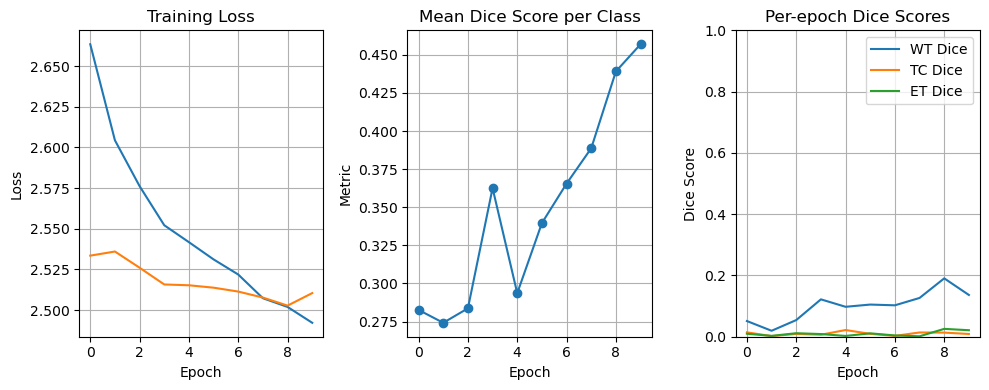

In [11]:
num_epochs = 10 # TODO: change to 50
dir = f'./runs/run_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
progress = ProgressBar()
tb = TensorBoard(path=dir)
checkpoints = Backup(path=dir, every=5)

trainer_1 = Att3DUNET_Trainer(model_1, optimizer_1, loss_fn, dice_score, device=device, use_torchio=False)
checkpoints.attach_trainer(trainer_1)
trainer_1.tracker.loggers = [progress, tb, checkpoints]

trainer_1.train(train_loader=train_dataloader, val_loader=validation_dataloader, epochs=num_epochs)

In [14]:
VALIDATION_ROOT_DIR  = './MICCAI-LH-BraTS2025-MET-Challenge-Validation/'

fullval_dataset = BrainMetFullVolumeDataset(root_dir=VALIDATION_ROOT_DIR)
full_validation_dataset = DataLoader(fullval_dataset, batch_size=1, num_workers=0, shuffle=False)

In [15]:
# === Setup ===
model_1.eval()
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
save_dir = f"./results/res_nopost_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

# === Inference Loop ===
for i, (inputs, datapoint_name) in enumerate(tqdm(full_validation_dataset, desc="Predicting")):
    inputs = inputs.to("cuda")

    with torch.no_grad():
        logits, _ = model_1(inputs)
        preds = torch.argmax(logits, dim=1)

    pred_np = preds.squeeze(0).cpu().numpy().astype(np.uint8)
    affine = np.eye(4)  # You could optionally load one of the input affines here

    pred_nii = nib.Nifti1Image(pred_np, affine)
    save_path = os.path.join(save_dir, datapoint_name[0] + "-seg.nii.gz")
    nib.save(pred_nii, save_path)

Predicting: 100%|██████████| 179/179 [10:04<00:00,  3.38s/it]


# Post-processing

In [16]:
from scipy.ndimage import label, sum as ndi_sum, binary_closing
from surface_distance import compute_surface_distances

def remove_small_regions(seg, min_size=100):
    result = np.copy(seg)
    for c in np.unique(seg):
        if c == 0: continue
        binary = (seg == c)
        labeled, num = label(binary)
        sizes = ndi_sum(binary, labeled, range(1, num + 1))
        for i, size in enumerate(sizes):
            if size < min_size:
                result[labeled == (i + 1)] = 0
    return result

def morph_close(seg):
    result = np.zeros_like(seg)
    for c in np.unique(seg):
        if c == 0: continue
        binary = (seg == c)
        closed = binary_closing(binary)
        result[closed] = c
    return result

def compute_braTS_dice(pred, target, num_classes=5):
    eps = 1e-5
    dice_scores = {}

    pred_wt = (pred > 0)  # WT: whole tumor
    target_wt = (target > 0)

    pred_tc = (pred == 1) | (pred == 3) | (pred == 4)  # Tumor Core: NCR, ET, RC => labels 1, 3, 4
    target_tc = (target == 1) | (target == 3) | (target == 4)


    pred_et = (pred == 3)  # ET: enhancing only
    target_et = (target == 3)

    def dice(x, y):
        x = x.float()
        y = y.float()
        intersection = (x * y).sum()
        return (2. * intersection + eps) / (x.sum() + y.sum() + eps)

    dice_scores['WT'] = dice(pred_wt, target_wt)
    dice_scores['TC'] = dice(pred_tc, target_tc)
    dice_scores['ET'] = dice(pred_et, target_et)

    return dice_scores

def compute_all_metrics(pred, target, spacing=(1.0, 1.0, 1.0), tolerance_mm=1.0):
    eps = 1e-5
    def sensitivity(p, t):
        tp = (p & t).sum()
        fn = (~p & t).sum()
        return tp / (tp + fn + eps)

    def specificity(p, t):
        tn = (~p & ~t).sum()
        fp = (p & ~t).sum()
        return tn / (tn + fp + eps)

    def precision(p, t):
        tp = (p & t).sum()
        fp = (p & ~t).sum()
        return tp / (tp + fp + eps)

    def nsd(pred_bin, target_bin, spacing, tolerance):
        # Ensure 3D shape: (H, W, D)
        pred_np = pred_bin.squeeze().cpu().numpy().astype(np.bool_)
        target_np = target_bin.squeeze().cpu().numpy().astype(np.bool_)

        sd = compute_surface_distances(
            target_np, pred_np, spacing
        )
        dist = sd["distances_pred_to_gt"]
        if dist.size == 0:
            return 1.0 if target_np.sum() == 0 and pred_np.sum() == 0 else 0.0
        return np.mean(dist <= tolerance)

    def get_mask(x, region):
        if region == "WT":
            return (x > 0)
        elif region == "TC":
            return (x == 1) | (x == 3) | (x == 4)
        elif region == "ET":
            return (x == 3)
        else:
            raise ValueError(f"Unknown region: {region}")

    results = {}

    for region in ["WT", "TC", "ET"]:
        pred_mask = get_mask(pred, region)
        target_mask = get_mask(target, region)

        results[region] = {
            "NSD": nsd(pred_mask, target_mask, spacing, tolerance_mm),
            "Sensitivity": sensitivity(pred_mask, target_mask).item(),
            "Specificity": specificity(pred_mask, target_mask).item(),
            "Precision": precision(pred_mask, target_mask).item(),
        }

    return results

In [17]:
TRAIN_ROOT_DIR  = './MICCAI-LH-BraTS2025-MET-Challenge-Training/'
HELPER_ROOT_DIR = './training_helper/'

# !--------------------------------------------------------------
dataset = BrainMetPytorchDatasetValidation(TRAIN_ROOT_DIR)
# !--------------------------------------------------------------

train_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1])

validation_loader = DataLoader(validation_dataset, batch_size=1, num_workers=0, shuffle=False)
print(len(validation_loader))

Found UCSD-Training subfolder: ./MICCAI-LH-BraTS2025-MET-Challenge-Training/UCSD - Training
Total # samples: 1296 in ./MICCAI-LH-BraTS2025-MET-Challenge-Training/

129


In [ ]:
@torch.no_grad()
def evaluate_and_compare(model, data: DataLoader):
    model.eval()
    device = next(model.parameters()).device

    def init_stats():
        return {"WT": [], "TC": [], "ET": []}

    pre_metrics = {
        "Dice": init_stats(), "NSD": init_stats(),
        "Sensitivity": init_stats(), "Specificity": init_stats(), "Precision": init_stats()
    }

    post_metrics = {
        "Dice": init_stats(), "NSD": init_stats(),
        "Sensitivity": init_stats(), "Specificity": init_stats(), "Precision": init_stats()
    }

    for batch_idx, batch in enumerate(tqdm(data, desc="Evaluating")):
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)
        targets = targets.squeeze(1)

        outputs,  _ = model(inputs) # output, _ = for attention unet
        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)

        for i in range(preds.shape[0]):
            pred_raw = preds[i]
            target_i = targets[i]

            d_pre = compute_braTS_dice(pred_raw.unsqueeze(0), target_i.unsqueeze(0))
            m_pre = compute_all_metrics(pred_raw.unsqueeze(0), target_i.unsqueeze(0))
            for r in ["WT", "TC", "ET"]:
                pre_metrics["Dice"][r].append(d_pre[r])
                for k in ["NSD", "Sensitivity", "Specificity", "Precision"]:
                    pre_metrics[k][r].append(m_pre[r][k])

            post_np = morph_close(remove_small_regions(pred_raw.cpu().numpy()))
            post_tensor = torch.from_numpy(post_np).to(device)
            d_post = compute_braTS_dice(post_tensor.unsqueeze(0), target_i.unsqueeze(0))
            m_post = compute_all_metrics(post_tensor.unsqueeze(0), target_i.unsqueeze(0))
            for r in ["WT", "TC", "ET"]:
                post_metrics["Dice"][r].append(d_post[r])
                for k in ["NSD", "Sensitivity", "Specificity", "Precision"]:
                    post_metrics[k][r].append(m_post[r][k])

    def mean(lst): return float(torch.tensor(lst).mean())

    print(f"{'Metric':<15} {'Region':<6} {'Pre':>10} {'Post':>10}")
    print("-" * 45)
    for metric in ["Dice", "NSD", "Sensitivity", "Specificity", "Precision"]:
        for region in ["WT", "TC", "ET"]:
            pre_val = mean(pre_metrics[metric][region])
            post_val = mean(post_metrics[metric][region])
            print(f"{metric:<15} {region:<6} {pre_val:10.4f} {post_val:10.4f}")
evaluate_and_compare(model_1, validation_loader)

Evaluating:   1%|          | 1/129 [03:46<8:04:06, 226.92s/it]

In [ ]:
VALIDATION_ROOT_DIR  = './MICCAI-LH-BraTS2025-MET-Challenge-Validation/'

fullval_dataset = BrainMetFullVolumeDataset(root_dir=VALIDATION_ROOT_DIR)
full_validation_dataset = DataLoader(fullval_dataset, batch_size=1, num_workers=0, shuffle=False)

# === Setup ===
model_1.eval()
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
save_dir = f"./results/res_wipost_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

for i, (inputs, datapoint_name) in enumerate(tqdm(full_validation_dataset, desc="Predicting")):
    inputs = inputs.to("cuda")

    with torch.no_grad():
        logits, _ = model_1(inputs)
        preds = torch.argmax(logits, dim=1)

    pred_np = preds.squeeze(0).cpu().numpy().astype(np.uint8)

    # --- Post-processing ---
    pred_np = remove_small_regions(pred_np, min_size=100)
    pred_np = morph_close(pred_np)

    # --- Save as NIfTI ---
    affine = np.eye(4)
    pred_nii = nib.Nifti1Image(pred_np, affine)
    save_path = os.path.join(save_dir, datapoint_name[0] + "-seg.nii.gz")
    nib.save(pred_nii, save_path)